from IPython.core.display import ProgressBar
## 0. Computer vision libraries in PyTorch

* [`torchvision`] - base domain library for pytorch computer vision. Like these there are many like - torchaudio, text, recomendation, data, serve
* `torchvision.datasets` -  get datset for computer vision here
* `torchvision.models` - get pretrained computer vision models that you can lverage for your own Problem
* `torchvision.transform` - func for manipulating your vision data to be suitable for use with ML model
* `torch.utils.data.Dataset` - Base dataset class for PyTorch
* `torch.utils.data.DataLoader` - Create python iterable over a dataset

In [ ]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt


## 1. Getting a Dataset

In [ ]:
from numpy import test
# Setup training data
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 269kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.00MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.99MB/s]


In [ ]:
classes = train_data.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [ ]:
image, label = train_data[5524]
image.shape, classes[label]

(torch.Size([1, 28, 28]), 'Shirt')

### 1.2 Visualize as Image

Image shape: torch.Size([1, 28, 28])


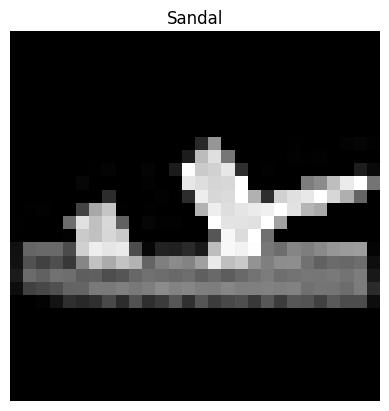

In [ ]:
import matplotlib.pyplot as plt

image, label = train_data[5440]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze(), cmap="gray")
plt.title(classes[label])
plt.axis("off")
plt.show()

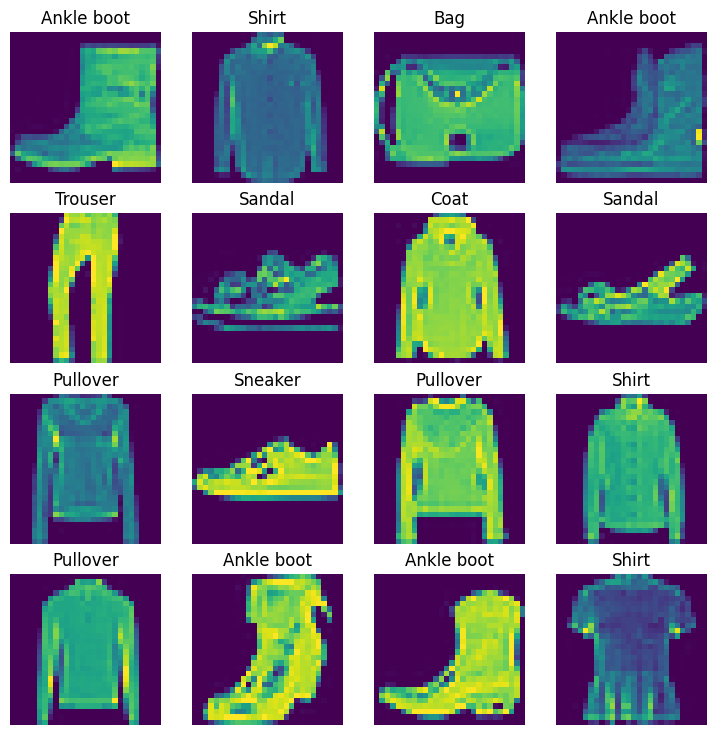

In [ ]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows, cols = 4,4
for i in range(1, rows*cols +1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  image, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(image.squeeze())
  plt.axis("off")
  plt.title(classes[label])

## 2. Prepare Dataloader
right now our data is very huge there for to train on 2000 img instead of 6000
it is more comupationally efficient and much better gradient decent

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)



In [ ]:
print(f"DataLoaded: {train_dataloader, test_dataloader}")
print(f"Length of Train_dataloader: {len(train_dataloader), BATCH_SIZE}")

DataLoaded: (<torch.utils.data.dataloader.DataLoader object at 0x7bab23f80b90>, <torch.utils.data.dataloader.DataLoader object at 0x7bab2aaa6240>)
Length of Train_dataloader: (1875, 32)


In [ ]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

## 3. Model 0: Build a baseline model
a baseline model is a simple model that you will try to improve upon with subsequent changes

In [ ]:
# Create a flatten layer
flatten_model = nn.Flatten()
X = train_features_batch[0]
output = flatten_model(X)

In [ ]:
from torch import nn
class FashionMNISHModelV0(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )

  def forward(self, x):
    return self.layer_stack(x)

In [ ]:
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
model_0 = FashionMNISHModelV0(input_shape=28*28, hidden_units=10, output_shape=len(classes))
model_0.to(device)

FashionMNISHModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): Linear(in_features=10, out_features=10, bias=True)
  )
)

'Bag'

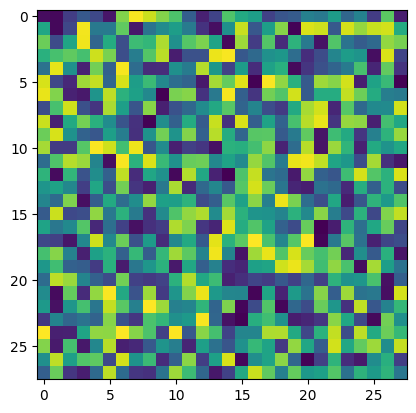

In [ ]:
dummy_x = torch.rand(1,1,28,28)
plt.imshow(dummy_x.squeeze())
classes[model_0(dummy_x).argmax()]

### 3.1 setup loss fn and optim
since we are working on multiple classes, use nn.crossentropy
sgd optimizer


In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 16.2 MB/s eta 0:00:00


In [ ]:
from torchmetrics import Accuracy

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

accuracy_fn = Accuracy(task="multiclass", num_classes=len(classes)).to(device)


### 3.2 Creating a func to time out experiments
we need models performance and how fast it runs

In [ ]:
from timeit import default_timer as timer
def print_train_time(start:float,end:float, device:str = None):
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

### 3.3 Creating train and test loop a model on batches of data
1. loop thorugh epoch
2. loop through training batches, perform training step, calculate the train loss per batch
3. loop through testing batches, perform testing steps, calculate the test loss per batch
4. print and time it

In [ ]:
from tqdm.auto import tqdm

torch.manual_seed(32)
time_start_on_cpu = timer()

epochs = 3

for e in tqdm(range(epochs)):
  print(f"Epoch: {e}\n--------")
  # Training
  train_loss = 0
  for batch, (X,y) in enumerate(train_dataloader):
    X,y = X.to(device), y.to(device)
    model_0.train()

    pred = model_0(X)

    loss = loss_fn(pred, y)
    train_loss += loss # accumullate train loss

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if batch % 500 == 0:
      print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

  train_loss /= len(train_dataloader)

  # Testing loop
  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for X_test,y_test in test_dataloader:
      X_test, y_test = X_test.to(device), y_test.to(device)
      test_pred = model_0(X_test)

      test_loss += loss_fn(test_pred, y_test)
      test_acc += accuracy_fn(test_pred.argmax(dim=1), y_test)

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

  # Print
  print(f"\nTrain Loss: {train_loss:.3f} | Test Loss: {test_loss:.3f} | Test Acc: {test_acc:.3f}")

time_end_on_cpu = timer()
total_time_on_cpu = print_train_time(time_start_on_cpu, time_end_on_cpu, device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
--------
Looked at 0/60000 samples
Looked at 16000/60000 samples
Looked at 32000/60000 samples
Looked at 48000/60000 samples

Train Loss: 0.635 | Test Loss: 0.546 | Test Acc: 0.807
Epoch: 1
--------
Looked at 0/60000 samples
Looked at 16000/60000 samples
Looked at 32000/60000 samples
Looked at 48000/60000 samples

Train Loss: 0.501 | Test Loss: 0.555 | Test Acc: 0.799
Epoch: 2
--------
Looked at 0/60000 samples
Looked at 16000/60000 samples
Looked at 32000/60000 samples
Looked at 48000/60000 samples

Train Loss: 0.472 | Test Loss: 0.531 | Test Acc: 0.812
Train time on cpu: 45.030 seconds


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

def eval_model(model: nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: nn.Module, accuracy_fn):
  """
  Returns a dictionary containing the results of model predicting on data_loader.
  """
  loss, acc = 0,0
  model.eval()
  with torch.inference_mode():
    for X,y in tqdm(data_loader):
      X,y = X.to(device), y.to(device)
      # Make predictions
      y_pred = model(X)

      # Accumulate the loss and acc values per batch
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_pred.argmax(dim=1), y)
    # Scale the loss and acc to find the avg loss and acc per batch
    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name":model.__class__.__name__, "model_loss": loss.item(), "model_acc": acc}

# Calculate Model 0 results on test dataset
model_0_results = eval_model(model_0, test_dataloader, loss_fn, accuracy_fn)
model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISHModelV0',
 'model_loss': 0.5311262011528015,
 'model_acc': tensor(0.8118)}

## 5. Setup device agnostic code  

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## 6. building model which is device agnostic with non linearity

In [ ]:
class FasionMNITSModelV1(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(input_shape, hidden_units),
        nn.ReLU(),
        nn.Linear(hidden_units, output_shape),
        nn.Softmax(dim=1)
    )

  def forward(self,x):
    return self.layer_stack(x)

In [ ]:
torch.manual_seed(42)
model_1 = FasionMNITSModelV1(input_shape=28*28, hidden_units=10, output_shape=len(classes)).to(device)
next(model_1.parameters()).device

device(type='cpu')

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)
accuracy_fn = Accuracy(task="multiclass", num_classes=len(classes)).to(device)

##. 6.2 Training and eval a model function
* train_step()
* test_step()

In [ ]:
def train_step(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer,
               accuracy_fn, device: torch.device = device):
  train_loss, train_acc = 0, 0

  model.train()
  for batch, (X,y) in enumerate(data_loader):
    X,y = X.to(device), y.to(device)
    pred = model(X)
    loss = loss_fn(pred, y)
    acc = accuracy_fn(pred.argmax(dim=1), y)
    train_loss += loss # accumullate train loss
    train_acc += acc # accumullate acc
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if batch % 500 == 0:
      print(f"Looked at {batch * len(X)}/{len(data_loader.dataset)} samples")

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"\nTrain Loss: {train_loss:.3f} | Train Accuracy: {train_acc:.3f}\n")

def test_step(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer,
               accuracy_fn, device: torch.device = device):
  # Testing loop
  test_loss, test_acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X_test,y_test in data_loader:
      X_test, y_test = X_test.to(device), y_test.to(device)
      test_pred = model(X_test)

      test_loss += loss_fn(test_pred, y_test)
      test_acc += accuracy_fn(test_pred.argmax(dim=1), y_test)

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

  # Print
  print(f"\nTest Loss: {test_loss:.3f} | Test Acc: {test_acc:.3f}")


In [ ]:
torch.manual_seed(42)
from timeit import default_timer as timer

time_start_on_cuda = timer()

epochs = 10
for e in tqdm(range(epochs)):
  print(f"Epoch: {e}\n--------------")
  train_step(model = model_1, data_loader = train_dataloader,
             loss_fn=loss_fn, optimizer=optimizer,
             accuracy_fn=accuracy_fn, device=device)
  test_step(model=model_1, data_loader=test_dataloader,
            loss_fn=loss_fn, optimizer=optimizer,
            accuracy_fn=accuracy_fn, device=device)

time_end_on_cuda = timer()

total_time_on_cuda = print_train_time(time_start_on_cuda, time_end_on_cuda, device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
--------------
Looked at 0/60000 samples
Looked at 16000/60000 samples
Looked at 32000/60000 samples
Looked at 48000/60000 samples

Train Loss: 1.948 | Train Accuracy: 0.530


Test Loss: 1.830 | Test Acc: 0.644
Epoch: 1
--------------
Looked at 0/60000 samples
Looked at 16000/60000 samples
Looked at 32000/60000 samples
Looked at 48000/60000 samples

Train Loss: 1.818 | Train Accuracy: 0.649


Test Loss: 1.815 | Test Acc: 0.650
Epoch: 2
--------------
Looked at 0/60000 samples
Looked at 16000/60000 samples
Looked at 32000/60000 samples
Looked at 48000/60000 samples

Train Loss: 1.808 | Train Accuracy: 0.656


Test Loss: 1.809 | Test Acc: 0.653
Epoch: 3
--------------
Looked at 0/60000 samples
Looked at 16000/60000 samples
Looked at 32000/60000 samples
Looked at 48000/60000 samples

Train Loss: 1.804 | Train Accuracy: 0.660


Test Loss: 1.804 | Test Acc: 0.658
Epoch: 4
--------------
Looked at 0/60000 samples
Looked at 16000/60000 samples
Looked at 32000/60000 samples
Looked at 

In [ ]:
model_0_results

{'model_name': 'FashionMNISHModelV0',
 'model_loss': 0.5311262011528015,
 'model_acc': tensor(0.8118)}

In [ ]:
model_1_results = eval_model(model=model_1, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)
model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FasionMNITSModelV1',
 'model_loss': 1.7218700647354126,
 'model_acc': tensor(0.7410)}

**Note** sometimes, depending on your data/hardward you might find that your model trains faster on CPU than GPU

> 1. It could be that the overhead of copying data/ model to and from the GPU outwieghts the compute benefits offered by the GPU
> 2. The hardware you are using has a better CPU in terms compute capability then GPU

## Model 2: Building a convolutional NN
Used mainly for detecting paterns in images using CONV2D filter, pooling, padding, etc

In [ ]:
class FasionMNITSModelV2(nn.Module):
  def __init__(self, input, hidden, output):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(input,hidden,kernel_size=3,padding=1,stride=1),
        nn.ReLU(),
        nn.Conv2d(hidden,hidden,kernel_size=3,padding=1,stride=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(hidden,hidden,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden,hidden,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden*7*7, out_features=output)
    )

  def forward(self,x):
    x = self.conv_block_1(x)
    # print(f"Conv 1 {x.shape}")
    x = self.conv_block_2(x)
    # print(f"Conv 2 {x.shape}")
    x = self.classifier(x)
    # x = nn.Flatten()(x)
    # print(f"Classifier {x.shape}")
    return x

In [ ]:
torch.manual_seed(42)
model_2 = FasionMNITSModelV2(input=1, hidden=10, output=len(classes)).to(device)
model_2

FasionMNITSModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

### 7.1 Stepping thourgh nn conv2d


In [ ]:
torch.manual_seed(42)

# Create sample batch of random numbers with same size as image batch
images = torch.randn(size=(32, 3, 64, 64)) # [batch_size, color_channels, height, width]
test_image = images[0] # get a single image for testing
print(f"Image batch shape: {images.shape} -> [batch_size, color_channels, height, width]")
print(f"Single image shape: {test_image.shape} -> [color_channels, height, width]")


Image batch shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Single image shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]


In [ ]:
torch.manual_seed(42)

# Create a convolutional layer with same dimensions as TinyVGG
# (try changing any of the parameters and see what happens)
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=1) # also try using "valid" or "same" here

# Pass the data through the convolutional layer
conv_layer(test_image).shape

torch.Size([10, 64, 64])

## 7.2 Stepping thourgh max2d layer

In [ ]:
max_pool_layer = nn.MaxPool2d(kernel_size=2)
"image",test_image.shape, "\nconv2d", conv_layer(test_image).shape, "\nmax2d", max_pool_layer(conv_layer(test_image)).shape

('image',
 torch.Size([3, 64, 64]),
 '\nconv2d',
 torch.Size([10, 64, 64]),
 '\nmax2d',
 torch.Size([10, 32, 32]))

In [ ]:
rand_image_tensor = torch.randn(size=(1,28,28)).to(device)
classes[model_2(rand_image_tensor.unsqueeze(0)).argmax(1)]

'Pullover'

### 7.3 Setup loss and optim

In [ ]:
from torchmetrics import Accuracy
loss_fn = nn.CrossEntropyLoss()
accuracy_fn = Accuracy(task="multiclass", num_classes=len(classes)).to(device)
optimizer = torch.optim.SGD(params=model_2.parameters(),lr=0.1)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

from timeit import default_timer as timer

time_start_model_2 = timer()
epochs = 3
for e in tqdm(range(epochs)):
  print(f"Epoch: {e}\n--------------")
  train_step(model=model_2, data_loader=train_dataloader,
             loss_fn=loss_fn, optimizer=optimizer,
             accuracy_fn=accuracy_fn, device=device)
  test_step(model=model_2, data_loader=train_dataloader,
             loss_fn=loss_fn, optimizer=optimizer,
             accuracy_fn=accuracy_fn, device=device)

time_end_model_2 = timer()

total_train_time_model_2 = print_train_time(time_start_model_2, time_end_model_2, device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
--------------
Looked at 0/60000 samples
Looked at 16000/60000 samples
Looked at 32000/60000 samples
Looked at 48000/60000 samples

Train Loss: 0.595 | Train Accuracy: 0.784


Test Loss: 0.371 | Test Acc: 0.868
Epoch: 1
--------------
Looked at 0/60000 samples
Looked at 16000/60000 samples
Looked at 32000/60000 samples
Looked at 48000/60000 samples

Train Loss: 0.364 | Train Accuracy: 0.869


Test Loss: 0.361 | Test Acc: 0.875
Epoch: 2
--------------
Looked at 0/60000 samples
Looked at 16000/60000 samples
Looked at 32000/60000 samples
Looked at 48000/60000 samples

Train Loss: 0.325 | Train Accuracy: 0.883


Test Loss: 0.320 | Test Acc: 0.887
Train time on cpu: 273.472 seconds


In [ ]:
model_2_result = eval_model(model_2, test_dataloader, loss_fn, accuracy_fn)
model_2_result

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FasionMNITSModelV2',
 'model_loss': 0.34938228130340576,
 'model_acc': tensor(0.8746)}

In [ ]:
model_0_results, model_1_results, model_2_result

({'model_name': 'FashionMNISHModelV0',
  'model_loss': 0.5311262011528015,
  'model_acc': tensor(0.8118)},
 {'model_name': 'FasionMNITSModelV1',
  'model_loss': 1.7218700647354126,
  'model_acc': tensor(0.7410)},
 {'model_name': 'FasionMNITSModelV2',
  'model_loss': 0.34938228130340576,
  'model_acc': tensor(0.8746)})

In [ ]:
import pandas as pd

compare_results = pd.DataFrame([model_0_results, model_1_results, model_2_result])

In [ ]:
compare_results

,model_name,model_loss,model_acc
0,FashionMNISHModelV0,0.531126,tensor(0.8118)
1,FasionMNITSModelV1,1.721870,tensor(0.7410)
2,FasionMNITSModelV2,0.349382,tensor(0.8746)


In [ ]:
compare_results["training_time"] = [total_time_on_cpu,total_time_on_cuda, total_train_time_model_2]
compare_results

,model_name,model_loss,model_acc,training_time
0,FashionMNISHModelV0,0.531126,tensor(0.8118),45.029948
1,FasionMNITSModelV1,1.721870,tensor(0.7410),141.489386
2,FasionMNITSModelV2,0.349382,tensor(0.8746),273.472196


<Axes: ylabel='model_name'>

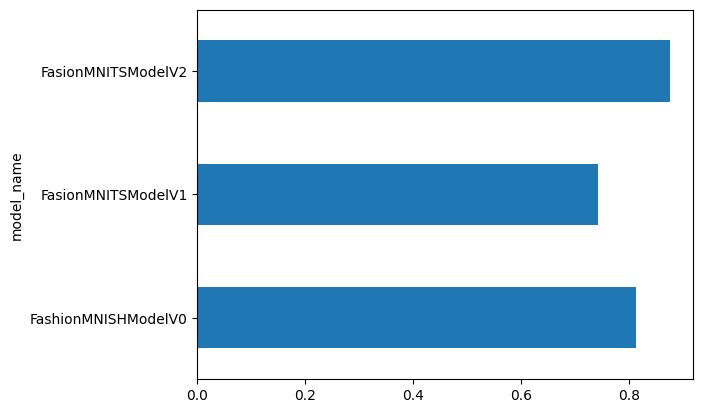

In [ ]:
# Visualize out model result
import numpy as np
compare_results["model_acc"] = np.array([x.cpu().numpy() for x in compare_results["model_acc"]])
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")


In [ ]:
def make_prediction(model:torch.nn.Module,
                     data:list,
                     device:torch.device = device):
  pred_probs = []
  model.eval()
  with torch.inference_mode():
    for sample in data:
      sample = torch.unsqueeze(sample, dim=0).to(device)
      pred_logit = model(sample)
      pred_prob = torch.softmax(pred_logit, dim=1)
      pred_probs.append(pred_prob.cpu())
  return torch.stack(pred_probs)

In [ ]:
import random
# random.seed(42)

test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)

test_samples[0].shape

torch.Size([1, 28, 28])

'Trouser'

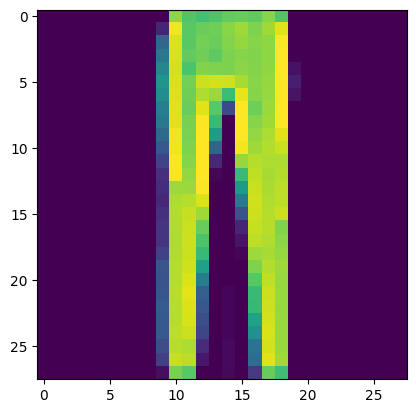

In [ ]:
plt.imshow(test_samples[8].squeeze())
classes[test_labels[8]]

In [ ]:
pred_probs = make_prediction(model_2, test_samples)
pred_probs[:2]

tensor([[[2.0768e-02, 2.5721e-03, 5.8456e-01, 6.8663e-03, 1.5234e-01,
          1.5389e-04, 2.5660e-02, 2.8478e-04, 2.0655e-01, 2.4597e-04]],

        [[4.3655e-04, 3.2667e-04, 1.2169e-01, 6.8715e-04, 8.3558e-01,
          9.9187e-07, 2.8419e-03, 3.0567e-05, 3.8391e-02, 1.8532e-05]]])

In [ ]:
pred_classes = pred_probs.squeeze().argmax(dim=1)
pred_classes

tensor([2, 4, 6, 3, 2, 2, 0, 1, 1])

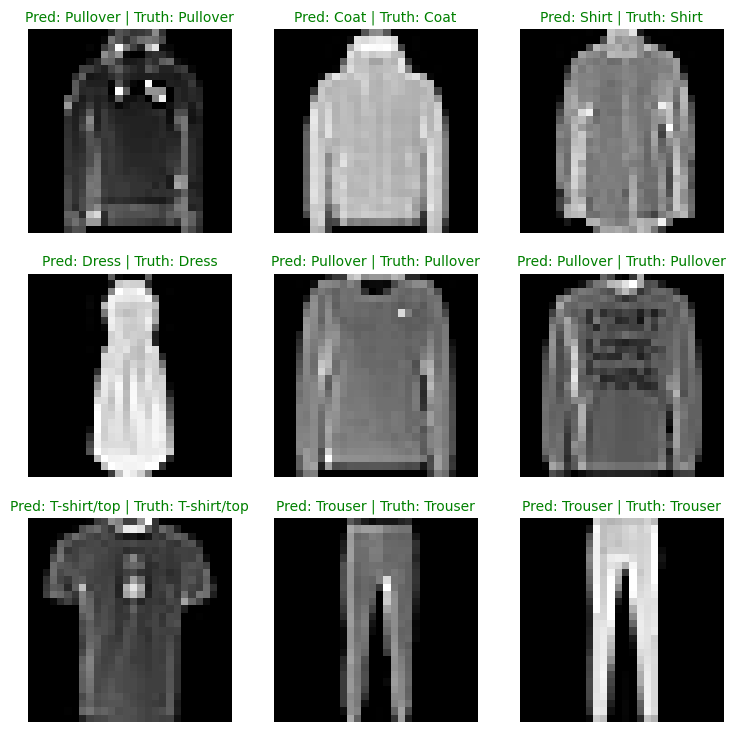

In [ ]:
plt.figure(figsize=(9,9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  plt.subplot(nrows, ncols, i+1)
  plt.imshow(sample.squeeze(), cmap="gray")
  pred_label = classes[pred_classes[i]]
  truth_label = classes[test_labels[i]]
  title_text = (f"Pred: {pred_label} | Truth: {truth_label}")
  plt.axis(False)
  if pred_label == truth_label:
    plt.title(title_text, fontsize = 10, c = "g")
  else:
    plt.title(title_text, fontsize = 10, c = "r")


## 10. confusion matrix
1. make pred
2. make confusion matrix
3. plot the confusion matrix using mlxtent

In [74]:
import mlxtend

In [78]:
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X,y in tqdm(test_dataloader, desc="Making predictions....."):
    X,y = X.to(device), y.to(device)
    y_logits = model_2(X)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    y_preds.append(y_pred.cpu())

  # Concat
  y_pred_tensor = torch.cat(y_preds)
  y_pred_tensor

Making predictions.....:   0%|          | 0/313 [00:00<?, ?it/s]

In [79]:
y_pred_tensor

tensor([9, 2, 1,  ..., 8, 1, 5])

In [87]:
try:
  import torchmetrics, mlxtend
  print(mlxtend.__version__)
  assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend version should be 0.19 or higher"
except:
  !pip install mlxtend --upgrade torchmetrics
  import torchmetrics, mlxtend
  print(mlxtend.__version__)

0.23.4


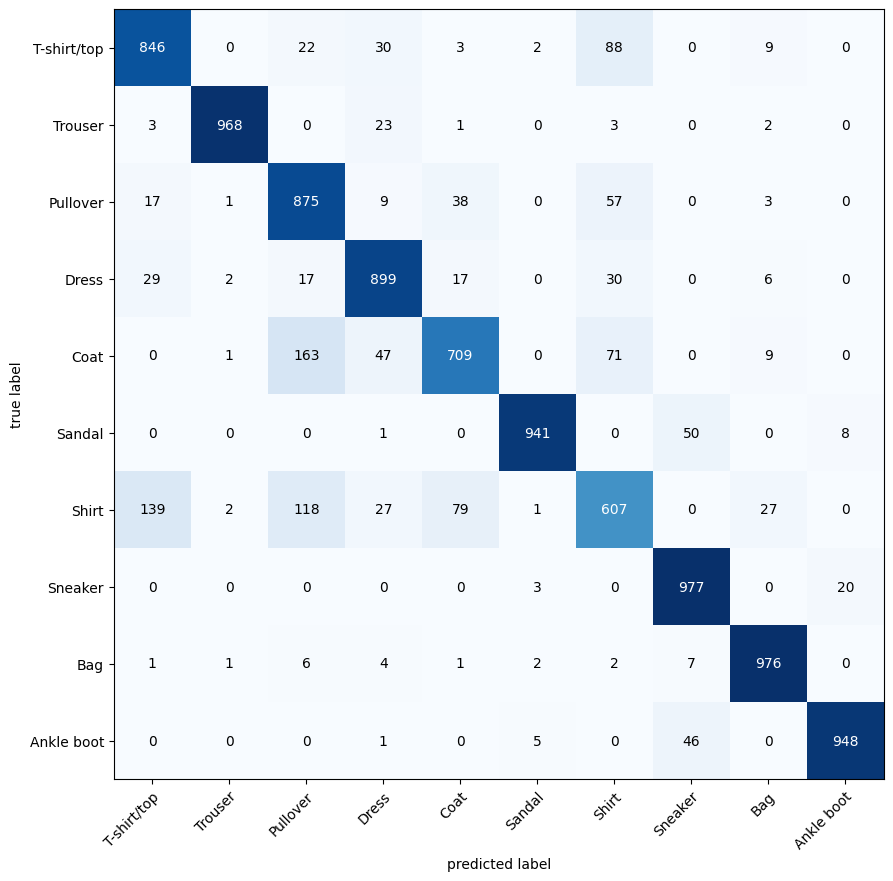

In [94]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# Setup confusion matrix instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(classes), task="multiclass")
confmat_tensor = confmat(y_pred_tensor, test_data.targets)

# Plot Conf Mat
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names = classes,
    figsize=(10,10)
)

## 11. Saving model

In [97]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Create model save
MODEL_NAME = "03_conv_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj=model_2.state_dict(), f=MODEL_SAVE_PATH)

In [102]:
loaded_model_2 = FasionMNITSModelV2(input=1, hidden=10, output=len(classes))
loaded_model_2.load_state_dict(torch.load(MODEL_SAVE_PATH))
loaded_model_2_result = eval_model(loaded_model_2, test_dataloader, loss_fn, accuracy_fn)

  0%|          | 0/313 [00:00<?, ?it/s]

In [105]:
model_2_result, loaded_model_2_result

({'model_name': 'FasionMNITSModelV2',
  'model_loss': 0.34938228130340576,
  'model_acc': tensor(0.8746)},
 {'model_name': 'FasionMNITSModelV2',
  'model_loss': 0.34938228130340576,
  'model_acc': tensor(0.8746)})

In [106]:
torch.isclose(torch.tensor(model_2_result["model_loss"]),
              torch.tensor(loaded_model_2_result["model_loss"]))

tensor(True)

# Exercise for 03